<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\tangb\AppData\Local\Temp\ipykernel_43868\4213694850.py:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')


=== 코호트별 유저 수 ===
cohort
01_초반(1-5)      24717
02_중초반(6-15)    19055
03_중반(16-30)    13790
04_후반(31-60)    12965
05_헤비(61+)      19662
Name: count, dtype: int64

=== 코호트별 리텐션 ===
                유저수  D1리텐션  D7리텐션  D1→D7유지율
cohort                                     
01_초반(1-5)    24717  0.068  0.013     0.191
02_중초반(6-15)  19055  0.265  0.039     0.147
03_중반(16-30)  13790  0.519  0.099     0.191
04_후반(31-60)  12965  0.707  0.208     0.294
05_헤비(61+)    19662  0.869  0.593     0.682


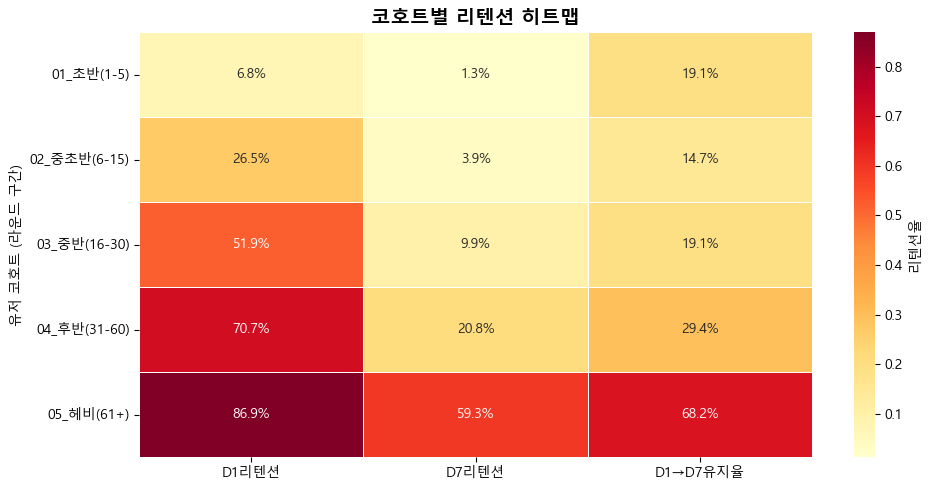

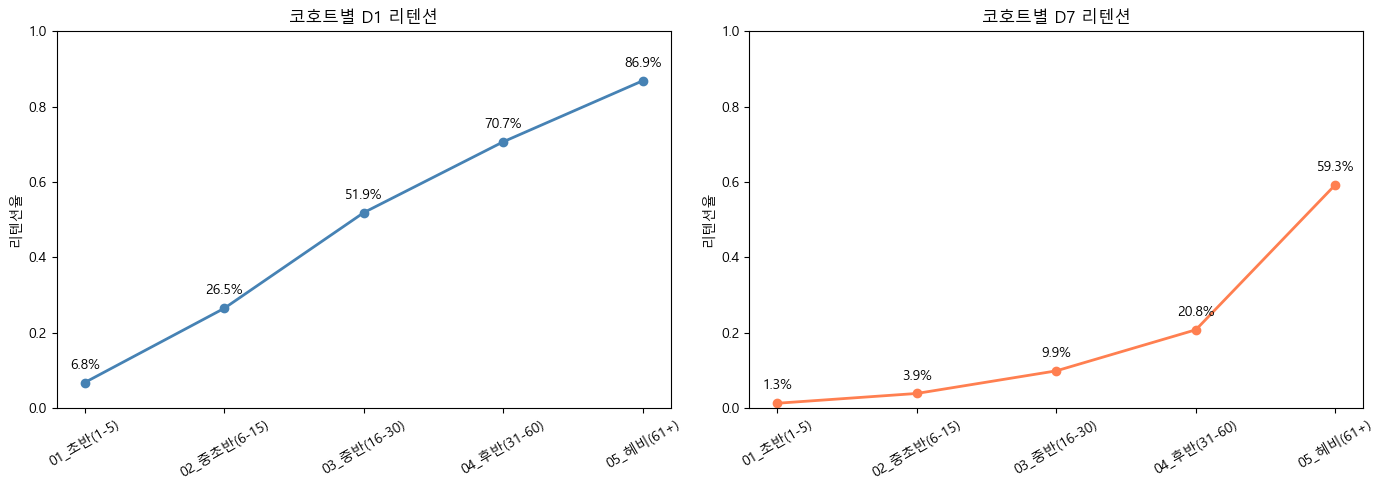


=== A/B 그룹 x 코호트별 D7 리텐션 ===
              gate_30 D7  gate_40 D7
cohort                              
01_초반(1-5)         0.012       0.013
02_중초반(6-15)       0.040       0.038
03_중반(16-30)       0.105       0.094
04_후반(31-60)       0.216       0.200
05_헤비(61+)         0.604       0.583


<Figure size 1000x500 with 0 Axes>

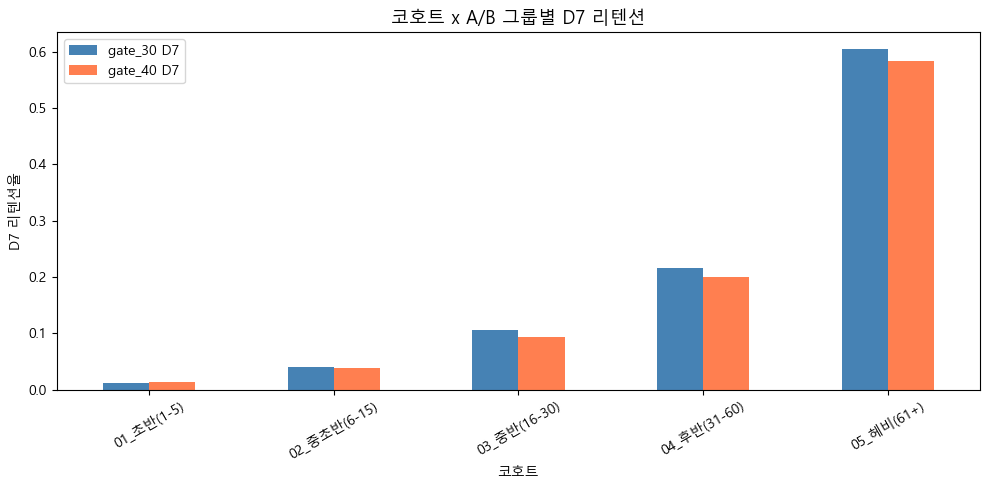

In [1]:
# 03_cohort_analysis.ipynb

# =====================
# 1. 라이브러리 로드
# =====================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')

# =====================
# 2. 코호트 기준 컬럼 생성
# 라운드 구간으로 유저 그룹 나누기
# =====================
def assign_cohort(rounds):
    if rounds <= 5:
        return '01_초반(1-5)'
    elif rounds <= 15:
        return '02_중초반(6-15)'
    elif rounds <= 30:
        return '03_중반(16-30)'
    elif rounds <= 60:
        return '04_후반(31-60)'
    else:
        return '05_헤비(61+)'

df['cohort'] = df['sum_gamerounds'].apply(assign_cohort)

# 코호트별 유저 수 확인
print("=== 코호트별 유저 수 ===")
print(df['cohort'].value_counts().sort_index())

# =====================
# 3. 코호트별 리텐션 계산
# =====================
cohort_retention = df.groupby('cohort').agg(
    유저수=('userid', 'count'),
    D1리텐션=('retention_1', 'mean'),
    D7리텐션=('retention_7', 'mean'),
).round(3)

cohort_retention['D1→D7유지율'] = (
    cohort_retention['D7리텐션'] / cohort_retention['D1리텐션']
).round(3)

print("\n=== 코호트별 리텐션 ===")
print(cohort_retention)

# =====================
# 4. 히트맵 시각화 (핵심!)
# =====================
heatmap_data = cohort_retention[['D1리텐션', 'D7리텐션', 'D1→D7유지율']]

plt.figure(figsize=(10, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1%',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': '리텐션율'}
)
plt.title('코호트별 리텐션 히트맵', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('유저 코호트 (라운드 구간)')
plt.tight_layout()
plt.savefig('../images/cohort_heatmap.png')
plt.show()

# =====================
# 5. 코호트별 리텐션 라인차트
# =====================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cohorts = cohort_retention.index.tolist()
d1_values = cohort_retention['D1리텐션'].tolist()
d7_values = cohort_retention['D7리텐션'].tolist()

# D1 리텐션
axes[0].plot(cohorts, d1_values, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('코호트별 D1 리텐션', fontsize=12)
axes[0].set_ylabel('리텐션율')
axes[0].set_ylim(0, 1)
for i, v in enumerate(d1_values):
    axes[0].annotate(f'{v:.1%}', (cohorts[i], v),
                     textcoords='offset points', xytext=(0, 10), ha='center')
axes[0].tick_params(axis='x', rotation=30)

# D7 리텐션
axes[1].plot(cohorts, d7_values, marker='o', color='coral', linewidth=2)
axes[1].set_title('코호트별 D7 리텐션', fontsize=12)
axes[1].set_ylabel('리텐션율')
axes[1].set_ylim(0, 1)
for i, v in enumerate(d7_values):
    axes[1].annotate(f'{v:.1%}', (cohorts[i], v),
                     textcoords='offset points', xytext=(0, 10), ha='center')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../images/cohort_linechart.png')
plt.show()

# =====================
# 6. A/B 그룹 x 코호트 교차 분석
# =====================
cross_d7 = df.groupby(['cohort', 'version'])['retention_7'].mean().unstack()
cross_d7.columns = ['gate_30 D7', 'gate_40 D7']
cross_d7 = cross_d7.round(3)

print("\n=== A/B 그룹 x 코호트별 D7 리텐션 ===")
print(cross_d7)

plt.figure(figsize=(10, 5))
cross_d7.plot(kind='bar', color=['steelblue', 'coral'], figsize=(10, 5))
plt.title('코호트 x A/B 그룹별 D7 리텐션', fontsize=13)
plt.ylabel('D7 리텐션율')
plt.xlabel('코호트')
plt.xticks(rotation=30)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../images/cohort_ab_compare.png')
plt.show()